In [1]:
import numpy as np
import pandas as pd
import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import os 
import sys
import glob as glob


countries_mapping = {
    "N/A": 0,
    "Argentina": 1,
    "Australia": 2,
    "Austria": 3,
    "Budapest": 4,
    "Chile": 5,
    "China": 6,
    "Colombia": 7,
    "Czech Republic": 8,
    "Denmark": 9,
    "Ecuador": 10,
    "Egypt": 11,
    "France": 12,
    "Germany": 13,
    "Ghana": 14,
    "Greece": 15,
    "Hong Kong": 16,
    "Hungary": 17,
    "Iceland": 18,
    "India": 19,
    "Ireland": 20,
    "Italy": 21,
    "Japan": 22,
    "Jordan": 23,
    "Kazakhstan": 24,
    "Kenya": 25,
    "Madagascar": 26,
    "Mexico": 27,
    "Mongolia": 28,
    "Morocco": 29,
    "Nepal": 30,
    "Netherlands": 31,
    "New Zealand": 32,
    "Panama": 33,
    "Peru": 34,
    "Portugal": 35,
    "South Africa": 36,
    "South Korea": 37,
    "Spain": 38,
    "Sweden": 39,
    "Switzerland": 40,
    "Taiwan": 41,
    "Tanzania": 42,
    "Trinidad & Tobago": 43,
    "Turks & Caicos Islands": 44,
    "Turks and Caicos Islands": 45,
    "United Kingdom": 46,
    "United States": 47
}

majors_mapping = {
    "N/A": 0,
    "Africana Studies": 1,
    "Anthropology": 2,
    "Art History": 3,
    "Asian Studies": 4,
    "Biochemistry": 5,
    "Biology": 6,
    "Chemistry": 7,
    "Chinese": 8,
    "Classics": 9,
    "Computer Science": 10,
    "Digital and Computational Studies": 11,
    "Earth and Oceanographic Science": 12,
    "Economics": 13,
    "Education": 14,
    "English": 15,
    "Environmental Studies": 16,
    "Francophone Studies": 17,
    "French": 18,
    "Gender, Sexuality, and Women's Studies": 19,
    "German": 20,
    "Government and Legal Studies": 21,
    "Hispanic Studies": 22,
    "History": 23,
    "Italian Studies": 24,
    "Japanese": 25,
    "LCL Studies": 26,
    "Latin American Studies": 27,
    "Mathematics": 28,
    "Middle Eastern and North African Studies": 29,
    "Music": 30,
    "Neuroscience": 31,
    "Philosophy": 32,
    "Physics": 33,
    "Psychology": 34,
    "REE Studies": 35,
    "Religion": 36,
    "Romance Language and Literatures": 37,
    "Russian": 38,
    "Sociology": 39,
    "Theater and Dance": 40,
    "Visual Arts": 41
}

class_mapping = {
    "2029": 0,
    "2028": 1,
    "2027": 2,
    "2026": 3,
}

In [2]:
image_folders = "./data/images/*"
# get all of the image paths 
image_paths = glob.glob(image_folders)
print(image_paths[:5])
# print(len(image_paths))

['./data/images/gobrien.jpg', './data/images/ybiyashev.jpg', './data/images/sborne.jpg', './data/images/sschubert.jpg', './data/images/rbryant.jpg']


In [3]:
data_info = pd.read_csv("./data/data_info.csv")
print(data_info.columns)
print(data_info.head())
# print(len(data_info))

Index(['Image ID', 'Name', 'Major', 'Study Abroad Location', 'Class Year',
       'ClassVals', 'MajorVals', 'CountryVals', 'Home State?'],
      dtype='str')
           Image ID              Name Major Study Abroad Location  Class Year  \
0  l.antonietti.jpg  Lucca Antonietti   NaN                   NaN        2029   
1        h.ladd.jpg        Henry Ladd   NaN                   NaN        2029   
2     o.benison.jpg      Owen Benison   NaN                   NaN        2029   
3      r.keenan.jpg       Ryan Keenan   NaN                   NaN        2029   
4     c.conover.jpg   Charlie Conover   NaN                   NaN        2029   

   ClassVals MajorVals  CountryVals    Home State?  
0          0         0            0  Massachusetts  
1          0         0            0  Massachusetts  
2          0         0            0    Connecticut  
3          0         0            0        Florida  
4          0         0            0          Maine  


In [4]:
# iterate through the rows of the data_info dataframe and print the country and major for each row

data_dict = {} 

for index, row in data_info.iterrows():
    image_id = row["Image ID"]
    class_label = row["ClassVals"]
    major_labels = row["MajorVals"]
    country_labels = row["CountryVals"]
    # print(f"Image ID: {image_id}, Class Label: {class_label}, Major Labels: {major_labels}, Country Labels: {country_labels}")

    if "," in major_labels:
        major_labels = major_labels.split(", ")
        major_labels = [int(label) for label in major_labels]
    else:        
        major_labels = [int(major_labels)]

    image_path = f"./data/images/{image_id}"

    data_dict[image_path] = {
        "class_label": int(class_label),
        "major_labels": major_labels,
        "country_labels": int(country_labels),
    }
    
    if f"./data/images/{image_id}" not in image_paths:
        print(f"Image ID: {image_id} not found in image paths")

        

In [5]:
for key, value in data_dict.items():
    print(f"Image Path: {key}, Class Label: {value['class_label']}, Major Labels: {value['major_labels']}, Country Labels: {value['country_labels']}")
    


Image Path: ./data/images/l.antonietti.jpg, Class Label: 0, Major Labels: [0], Country Labels: 0
Image Path: ./data/images/h.ladd.jpg, Class Label: 0, Major Labels: [0], Country Labels: 0
Image Path: ./data/images/o.benison.jpg, Class Label: 0, Major Labels: [0], Country Labels: 0
Image Path: ./data/images/r.keenan.jpg, Class Label: 0, Major Labels: [0], Country Labels: 0
Image Path: ./data/images/c.conover.jpg, Class Label: 0, Major Labels: [0], Country Labels: 0
Image Path: ./data/images/c.dakers.jpg, Class Label: 0, Major Labels: [0], Country Labels: 0
Image Path: ./data/images/n.reischmann.jpg, Class Label: 0, Major Labels: [0], Country Labels: 0
Image Path: ./data/images/k.lavallee.jpg, Class Label: 0, Major Labels: [0], Country Labels: 0
Image Path: ./data/images/c.ohara.jpg, Class Label: 0, Major Labels: [0], Country Labels: 0
Image Path: ./data/images/y.nee.jpg, Class Label: 0, Major Labels: [0], Country Labels: 0
Image Path: ./data/images/m.tripp.jpg, Class Label: 0, Major Lab

In [ ]:
# Process images
from PIL import Image 
import numpy as np
import torchvision.transforms as T

device = 'cpu'

transform = T.Compose([
        T.Resize((64, 64)), #resize to 64x64

        T.RandomHorizontalFlip(p=0.5), #data augmentation
        T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05), #data augmentation
        T.RandomRotation(degrees=7), #data augmentation

        T.ToTensor(),
        T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))#normalize
])

for key, value in data_dict.items():
    img = Image.open(key).convert('RGB')  
    img_tensor = transform(img).to(device)   
    data_dict[key]['image_tensor'] = img_tensor
    
    img = torch.tensor(np.array(img)).permute(2, 0, 1).float() / 255.0 #i removed unsqueeze because it was givinig mismatched tensor size errors in the training loop
    img = img.to(device)
    # print(f"Image Path: {key}, Image Shape: {img.shape}, type: {type(img)}")

    zeros_class = torch.zeros(4, dtype=torch.float32).to(device)
    zeros_country = torch.zeros(48, dtype=torch.float32).to(device)
    zeros_major = torch.zeros(42, dtype=torch.float32).to(device)

    class_label_one_hot = zeros_class.clone()
    class_label_one_hot[value['class_label']] = 1.0
    country_label_one_hot = zeros_country.clone()
    country_label_one_hot[value['country_labels']] = 1.0   
    major_label_one_hot = zeros_major.clone() #this shoudl have been outside loop
    for major_label in value['major_labels']:
        major_label_one_hot[major_label] = 1.0

    # print(f"Class Label One-Hot: {class_label_one_hot}, Country Label One-Hot: {country_label_one_hot}, Major Label One-Hot: {major_label_one_hot}")
    

    # store in dict 
    data_dict[key]['image_tensor'] = img_tensor
    data_dict[key]['class_label_one_hot'] = class_label_one_hot
    data_dict[key]['country_label_one_hot'] = country_label_one_hot
    data_dict[key]['major_label_one_hot'] = major_label_one_hot
    
    

In [7]:
class ClassMates(Dataset):
    def __init__(self, data_dict):
        self.data_dict = data_dict
        self.image_paths = list(data_dict.keys())
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        data = self.data_dict[image_path]
        return data['image_tensor'], data['class_label_one_hot'], data['country_label_one_hot'], data['major_label_one_hot']

In [8]:
dataset = ClassMates(data_dict)
dataloader = DataLoader(dataset, batch_size=5, shuffle=True)

for batch in dataloader:
    images, class_labels, country_labels, major_labels = batch
    print(f"Batch Image Shape: {images.shape}")
    print(f"Batch Class Labels Shape: {class_labels.shape}")
    print(f"Batch Country Labels Shape: {country_labels.shape}")
    print(f"Batch Major Labels Shape: {major_labels.shape}")

    break

Batch Image Shape: torch.Size([5, 3, 64, 64])
Batch Class Labels Shape: torch.Size([5, 4])
Batch Country Labels Shape: torch.Size([5, 48])
Batch Major Labels Shape: torch.Size([5, 42])


In [9]:
from models import DCGAN_gen, DCGAN_disc
import torch
import torch.nn as nn
import torch.optim as optim

# Initialize models
generator_DCGAN = DCGAN_gen().to(device)
discriminator_DCGAN = DCGAN_disc().to(device)

latent_dim = 100
condition_dim = 94 # 4 (Class) + 48 (Country) + 42 (Major)
channels = 3
img_size = 64

In [10]:
# Initialize Models
generator_DCGAN = DCGAN_gen().to(device)
discriminator_DCGAN = DCGAN_disc().to(device)

d_optimizer = optim.Adam(discriminator_DCGAN.parameters(), lr=0.0002, betas=(0.5, 0.999))
g_optimizer = optim.Adam(generator_DCGAN.parameters(), lr=0.0002, betas=(0.5, 0.999))
loss_fn = nn.BCELoss()

def noise_2d(batch_size):
    return torch.randn(batch_size, latent_dim, 1, 1, device=device)


In [ ]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

def show_generated_images(generator, num_images=16):
    generator.eval() # Put generator in evaluation mode
    
    with torch.no_grad():
        z = noise_2d(num_images)
        zeros_class = torch.zeros(num_images, 4, device=device)
        zeros_country = torch.zeros(num_images, 48, device=device)
        zeros_major = torch.zeros(num_images, 42, device=device)
        
        for i in range(num_images):
            rand_class = torch.randint(0, 4, (1,)).item()
            rand_country = torch.randint(0, 48, (1,)).item()
            rand_major = torch.randint(0, 42, (1,)).item()
            
            zeros_class[i, rand_class] = 1.0
            zeros_country[i, rand_country] = 1.0
            zeros_major[i, rand_major] = 1.0
            
        fake_conditions = torch.cat([zeros_class, zeros_country, zeros_major], dim=1)
        
        fake_images = generator(z, fake_conditions)
        
        fake_images = (fake_images + 1) / 2.0
        grid = make_grid(fake_images.cpu(), nrow=4, padding=2, normalize=False)
        
        plt.figure(figsize=(8, 8))
        plt.axis("off")
        plt.title("Generated Faces")
        plt.imshow(grid.permute(1, 2, 0)) 
        plt.show()
        
    generator.train() # Put generator back into training mode

Epoch 1/40 | D Loss: 0.2885 | G Loss: 8.3062
Epoch 2/40 | D Loss: 1.4901 | G Loss: 4.7577
Epoch 3/40 | D Loss: 0.8792 | G Loss: 3.3691
Epoch 4/40 | D Loss: 0.6258 | G Loss: 4.5239
Epoch 5/40 | D Loss: 1.2966 | G Loss: 6.4061


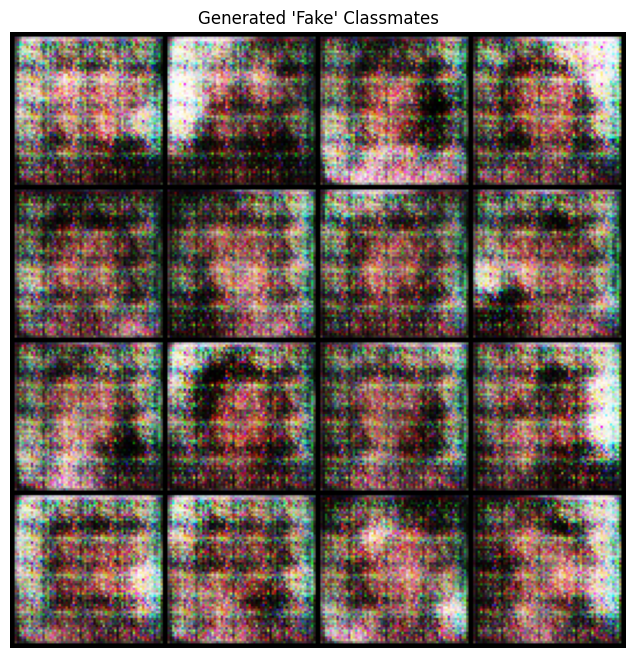

Epoch 6/40 | D Loss: 1.0122 | G Loss: 3.9710
Epoch 7/40 | D Loss: 0.3502 | G Loss: 3.3685
Epoch 8/40 | D Loss: 0.4579 | G Loss: 5.7606
Epoch 9/40 | D Loss: 1.2043 | G Loss: 2.5280
Epoch 10/40 | D Loss: 0.2023 | G Loss: 6.9874


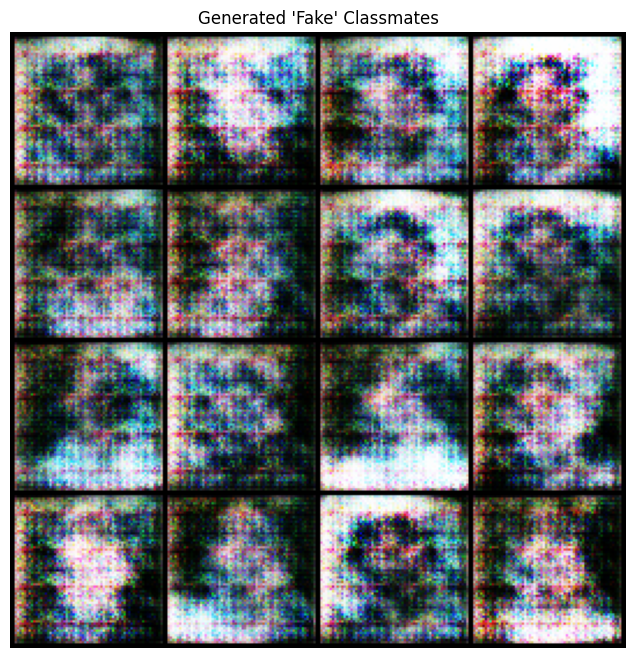

Epoch 11/40 | D Loss: 5.5874 | G Loss: 0.6541
Epoch 12/40 | D Loss: 1.2355 | G Loss: 5.7784
Epoch 13/40 | D Loss: 0.3536 | G Loss: 4.7991
Epoch 14/40 | D Loss: 0.5718 | G Loss: 2.1497
Epoch 15/40 | D Loss: 0.5207 | G Loss: 7.2548


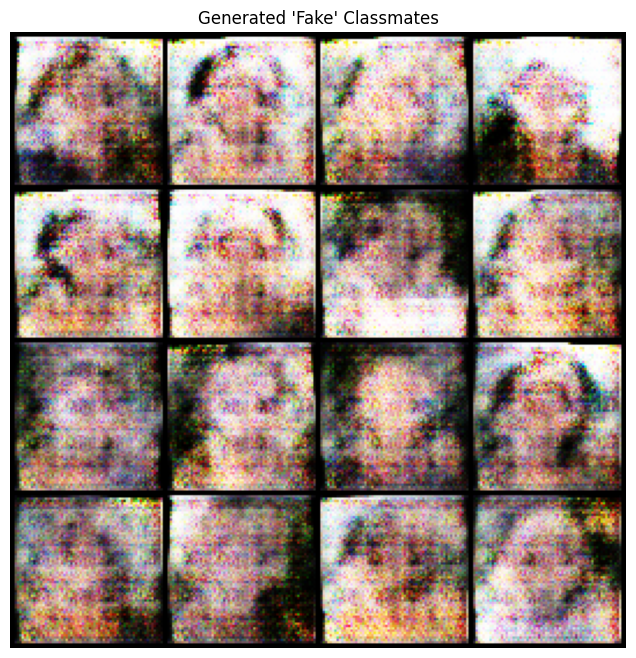

Epoch 16/40 | D Loss: 1.3963 | G Loss: 9.3193
Epoch 17/40 | D Loss: 1.0152 | G Loss: 2.8161
Epoch 18/40 | D Loss: 0.1928 | G Loss: 4.4437
Epoch 19/40 | D Loss: 0.3155 | G Loss: 5.4266
Epoch 20/40 | D Loss: 0.9247 | G Loss: 3.3629


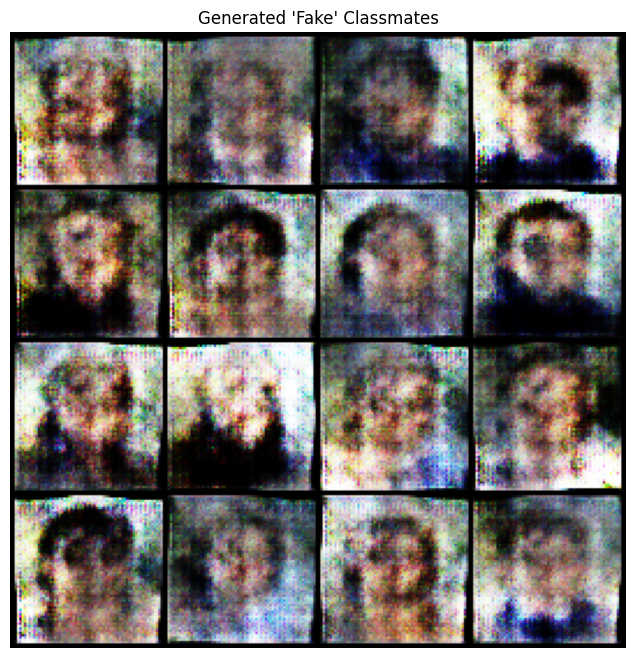

Epoch 21/40 | D Loss: 0.6970 | G Loss: 1.6708
Epoch 22/40 | D Loss: 2.4741 | G Loss: 2.5362
Epoch 23/40 | D Loss: 1.3026 | G Loss: 1.9978
Epoch 24/40 | D Loss: 1.0303 | G Loss: 2.5047
Epoch 25/40 | D Loss: 0.8858 | G Loss: 7.0928


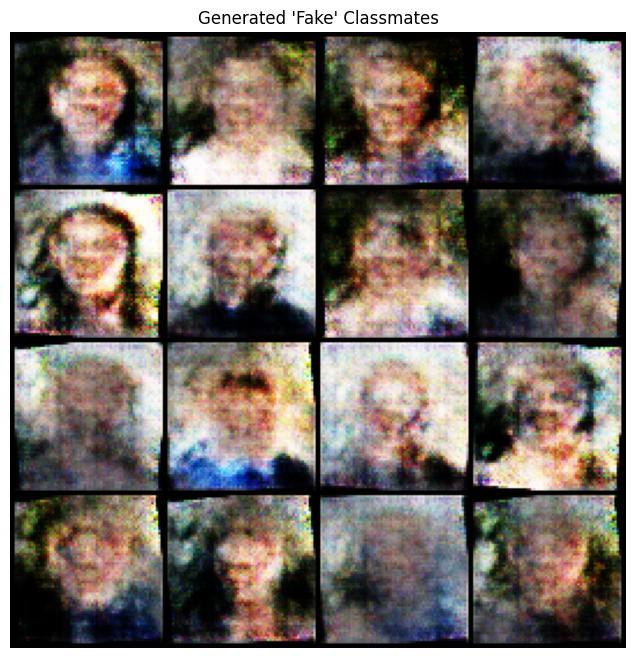

Epoch 26/40 | D Loss: 0.3157 | G Loss: 2.7434
Epoch 27/40 | D Loss: 0.0878 | G Loss: 7.3296
Epoch 28/40 | D Loss: 0.8230 | G Loss: 1.3445
Epoch 29/40 | D Loss: 0.1074 | G Loss: 5.4620
Epoch 30/40 | D Loss: 0.3901 | G Loss: 4.3965


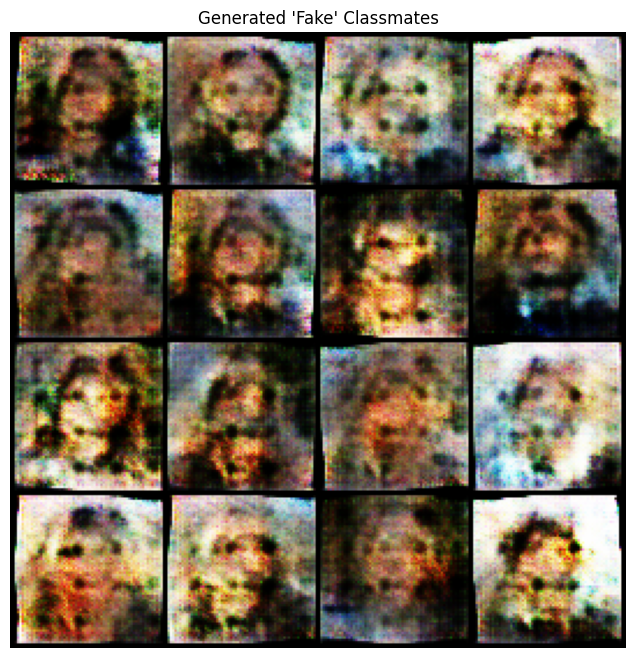

Epoch 31/40 | D Loss: 1.5929 | G Loss: 7.1904
Epoch 32/40 | D Loss: 0.2352 | G Loss: 7.5302
Epoch 33/40 | D Loss: 0.3511 | G Loss: 6.1616
Epoch 34/40 | D Loss: 0.2304 | G Loss: 6.4816
Epoch 35/40 | D Loss: 0.0733 | G Loss: 4.9127


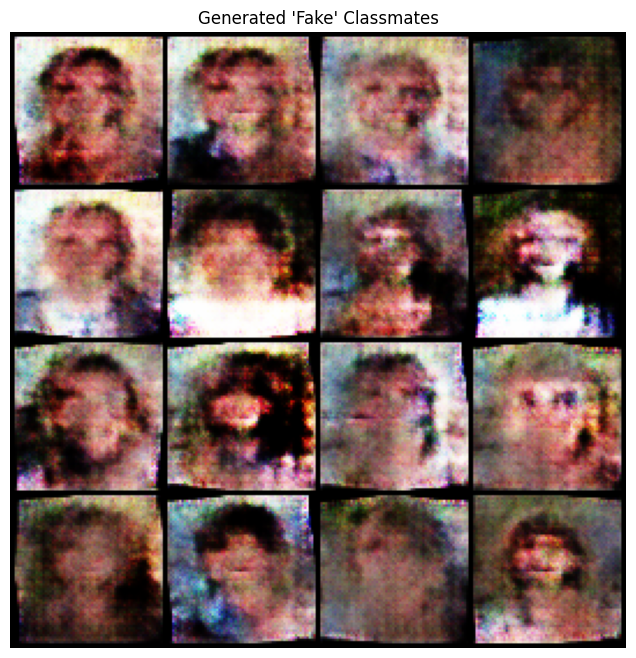

Epoch 36/40 | D Loss: 0.7713 | G Loss: 1.2950
Epoch 37/40 | D Loss: 0.8443 | G Loss: 8.9382
Epoch 38/40 | D Loss: 0.3209 | G Loss: 8.4209
Epoch 39/40 | D Loss: 0.1891 | G Loss: 3.9329
Epoch 40/40 | D Loss: 0.0855 | G Loss: 4.5382


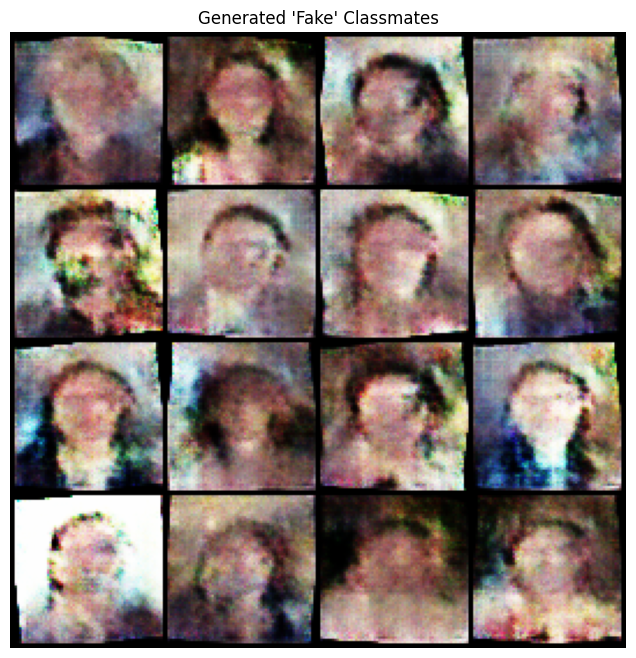

In [ ]:

num_epochs = 40 
for epoch in range(num_epochs):
    for i, (images, class_labels, country_labels, major_labels) in enumerate(dataloader):
        n_images = len(images)
        
        real_data = images.to(device)
        real_conditions = torch.cat([class_labels, country_labels, major_labels], dim=1).to(device)
        
        discriminator_DCGAN.zero_grad()
        
        pred_real = discriminator_DCGAN(real_data, real_conditions)
        loss_real = loss_fn(pred_real, torch.ones(n_images, 1).to(device))
        
        # Fake loss
        z = noise_2d(n_images)
        fake_data = generator_DCGAN(z, real_conditions)
        pred_fake = discriminator_DCGAN(fake_data.detach(), real_conditions)
        loss_fake = loss_fn(pred_fake, torch.zeros(n_images, 1).to(device))
        
        d_loss = loss_real + loss_fake
        d_loss.backward()
        d_optimizer.step()


        g_optimizer.zero_grad()
        pred_fake_gen = discriminator_DCGAN(fake_data, real_conditions)
        g_loss = loss_fn(pred_fake_gen, torch.ones(n_images, 1).to(device))
        
        g_loss.backward()
        g_optimizer.step()

    print(f"Epoch {epoch+1}/{num_epochs} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")
    if (epoch + 1) % 5 == 0:
        show_generated_images(generator_DCGAN, num_images=16)